# STUDENT NUMBER: 3439944

## ASSIGNMENT 1 (STOCHASTIC PROCESS)

### MATPMD4_Assignment1_3439944

### Question 1
Yes, I've gone through the instructions on the cover page and I understand them.

In [21]:
! pip install numpy

# Question and Answer 2a
 Recovering the missing transition probability

In a row-stochastic matrix, every row has to add up to 1 that's because each row represents the probabilities of moving from one state to all possible next states, and those chances have to cover every possibility.
Looking at row C, we have four known values and one missing one:
0.16 + 0.16 + 0.22 + x + 0.26 = 1
To find x, just add up what we already know:
0.16 + 0.16 + 0.22 + 0.26 = 0.80
Since the whole row needs to equal 1, the missing value is simply:
x = 1 − 0.80 = 0.20
And that's it plugging 0.20 back in brings the row sum back to 1, exactly as it should be.

In [22]:
# Add the known probabilities in row C
the_known = sum([0.16, 0.16, 0.22, 0.26])
print("Sum of known probabilities:", the_known)

# Subtract from 1 to find the missing probability
missing_value = round(1 - the_known, 2)
print("Missing probability (x):", missing_value)

Sum of known probabilities: 0.8
Missing probability (x): 0.2


In a stochastic matrix, each row holds a set of probabilities and since probabilities across all possible outcomes have to account for everything, they must add up to 1. That means the missing value in row C is simply 0.20, bringing the row's total to exactly 1.

##Question and Answer 2b
We're given the starting probabilities for each state : A = 13%, B = 24%, C = 32%, D = 28%, and E = 3%. which we can write as a row vector in decimal form:
π(0) = [0.13, 0.24, 0.32, 0.28, 0.03]
In a Markov chain, to find where the distribution goes next, we simply multiply the current state vector by the transition matrix on the right. So the pattern works like this:
π(1) = π(0)P to π(2) = π(1)P to π(3) = π(2)P
Or more generally: π(n+1) = π(n)P
Each step forward is just the previous distribution multiplied by P that's how the chain evolves over time.
Also, from Question 2a, we already found that x = 0.20.

In [23]:
import numpy as np

# Transition matrix — using x = 0.20 found in part (a)
P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.0,  1.0,  0.0,  0.0,  0.0 ],
    [0.16, 0.16, 0.22, 0.20, 0.26],
    [0.0,  0.0,  0.0,  1.0,  0.0 ],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

# Where everything starts — A=13%, B=24%, C=32%, D=28%, E=3%
pi_0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])

# Move the distribution forward one step at a time
pi_1 = pi_0 @ P   # after 1 step
pi_2 = pi_1 @ P   # after 2 steps
pi_3 = pi_2 @ P   # after 3 steps

print("After 1 step:", pi_1)
print("After 2 steps:", pi_2)
print("After 3 steps:", pi_3)

# What's happening under the hood:
# With each step, probability drains out of A, C, and E
# and piles up in B and D — the two absorbing states.
# By step three, B and D together hold most of the weight.

After 1 step: [0.0848 0.3084 0.0953 0.3655 0.146 ]
After 2 steps: [0.063716 0.369004 0.059966 0.428928 0.078386]
After 3 steps: [0.03943598 0.4042229  0.0368594  0.4667426  0.05273912]


Right from the first step, you can already see probability pulling away from A, C, and E and settling into B and D. By the second step that gap widens further, with B and D growing stronger while the remaining states are left sharing just a sliver of the total. By the third step, B and D are clearly running the show.
This is exactly the behaviour you'd expect from an absorbing Markov chain probability gradually drains out of the temporary states and gets "trapped" in the absorbing ones.
Looking at the transition matrix P makes it obvious why. Row B is [0, 1, 0, 0, 0] once the system lands in B, it never leaves. Row D is [0, 0, 0, 1, 0] same story. They're like black holes in the chain.
States A, C, and E, on the other hand, are transient they each have some chance of stepping into B or D, and once that happens, there's no coming back. So as we compute π(1), π(2), and π(3), the probabilities for A, C, and E quietly fade while B and D keep absorbing more and more of the weight. Each multiplication by P is essentially another nudge of probability flowing toward those two absorbing states until, eventually, that's where everything ends up.

##Question & Answer 2c
In an absorbing Markov chain, it helps to tidy things up by putting all the transient states first and the absorbing states last. When we do that, the transition matrix naturally falls into a clean block structure:

P = [ Q R / 0 I ]

Each block has a clear role. Q captures movement between transient states, R captures the drift from transient states into absorbing ones, the bottom-left 0 block confirms that you can never escape back out of an absorbing state, and the bottom-right I (identity matrix) simply says that once you're in an absorbing state, you stay put.
Since we already know from the original matrix that B and D are absorbing and A, C, and E are transient, we reorder the states as (A, C, E, B, D) and read off the blocks.

Matrix Q : transient to transient
This picks out how A, C, and E move among themselves:

From A to (A, C, E): 0.21, 0.15, 0.46

From C to (A, C, E): 0.16, 0.22, 0.26

From E to (A, C, E): 0.21, 0.18, 0.10

Q=[0.210.150.460.160.220.260.210.180.10]
Q = \begin{bmatrix} 0.21 & 0.15 & 0.46 \\ 0.16 & 0.22 & 0.26 \\ 0.21 & 0.18 & 0.10 \end{bmatrix}
Q=​0.210.160.21​0.150.220.18​0.460.260.10​​

Matrix R : transient to absorbing
This captures the probability of stepping from A, C, or E directly into B or D:

From A to (B, D): 0.07, 0.11
From C to (B, D): 0.16, 0.20
From E to (B, D): 0.27, 0.24

R=[0.070.110.160.200.270.24]R = \begin{bmatrix} 0.07 & 0.11 \\ 0.16 & 0.20 \\ 0.27 & 0.24 \end{bmatrix}R=​0.070.160.27​0.110.200.24​​

In [24]:
# Python uses 0 based indexing, so: A=0, B=1, C=2, D=3, E=4
transient_states = [0, 2, 4]   # the temporary states: A, C, E
absorbing_states = [1, 3]      # the trap states: B, D

# Slice out the Q block : transient to transient transitions
Q_matrix = P[np.ix_(transient_states, transient_states)]

# Slice out the R block : transient to absorbing transitions
R_matrix = P[np.ix_(transient_states, absorbing_states)]

print("Q =\n", Q_matrix)
print("R =\n", R_matrix)

Q =
 [[0.21 0.15 0.46]
 [0.16 0.22 0.26]
 [0.21 0.18 0.1 ]]
R =
 [[0.07 0.11]
 [0.16 0.2 ]
 [0.27 0.24]]


##Question and Answer 2d
One of the most useful tools in an absorbing Markov chain is something called the fundamental matrix, written as N and defined as:
N = (I − Q)^-1
We take the identity matrix I, subtract Q from it, and then invert the result. The inverse is guaranteed to exist because Q only describes transient behaviour, meaning probability doesn't stay trapped in those states forever, it always leaks out eventually. Mathematically, that means Q's eigenvalues all sit below 1, which is exactly the condition needed for the inverse to work.
What makes N so useful is what each entry actually tells you. The value at position N_ij answers a very natural question: if the chain starts in transient state i, how many times on average will it visit transient state j before finally getting absorbed?
So to get there in practice, the steps are straightforward: take Q, the transient to transient block we already built, form the matrix (I − Q), and invert it. What you get back is N, where every entry gives you the expected number of visits to each transient state depending on where you started.

In [25]:
I_matrix = np.eye(Q_matrix.shape[0])
N = np.linalg.inv(I_matrix - Q_matrix)

print("Fundamental Matrix N =\n", N)

Fundamental Matrix N =
 [[1.64119212 0.54556112 0.99643807]
 [0.49746757 1.53899334 0.69885928]
 [0.48243834 0.43509626 1.48338518]]


Question and Answer 2e
Once you have the fundamental matrix N, figuring out how long the chain is expected to wander before getting absorbed is surprisingly straightforward.
Since we know each entry N_ij tells you the expected number of visits to transient state j starting from state i. So if you just add up everything across row i, you get the total expected number of visits across all transient states combined and that total is exactly how many steps you'd expect before the chain finally gets pulled into an absorbing state.
For each starting state i, that's simply:
t_i = sum of all entries in row i of N
Or written more compactly in vector form, if 1 is just a column of ones (as long as the number of transient states):
t = N1
Each entry in t then answers a concrete question — if I start in transient state i, how many steps should I expect to take before landing in either B or D? That's your expected absorption time, one number per starting state.

In [26]:
t = N.sum(axis=1)  # sum each row of N

print("Expected steps before absorption (A, C, E):")
print(t)

Expected steps before absorption (A, C, E):
[3.18319131 2.7353202  2.40091979]


##Question and Answer 2f
Once we have N and R, finding the absorption probabilities is just one matrix multiplication away:
B = N × R
Each entry B_ik answers a simple question, if the chain starts in transient state i, what's the probability it eventually gets absorbed into state k? Every row of B is a complete picture for one starting state, and since absorption is guaranteed, each row must add up to 1.
In our case, with 3 transient states (A, C, E) and 2 absorbing states (B, D), B comes out as a 3×2 matrix:

Row 1 (starting from A): probability of ending up in B, probability of ending up in D
Row 2 (starting from C): probability of ending up in B, probability of ending up in D
Row 3 (starting from E): probability of ending up in B, probability of ending up in D

So no matter which transient state you begin in, B tells you exactly where you're most likely to end up once the chain finally settles.

In [27]:
# Multiply the fundamental matrix by the transient to absorbing block
# This gives us the probability of ending in each absorbing state
B_matrix = N @ R_matrix

# Each row corresponds to a starting state (A, C, E)
# Each column corresponds to an absorbing state (B, D)
print("Absorption probabilities (B, D) starting from (A, C, E):\n", B_matrix)

Absorption probabilities (B, D) starting from (A, C, E):
 [[0.47121151 0.52878849]
 [0.46975367 0.53024633]
 [0.50390009 0.49609991]]


##Question and Answer 3a
My student number is 3439944, so that gives me alpha = 3.43 and beta = 9.44.
With those values, the drift term  (1/alpha)sin(x)cos(t)  stays fairly small and keeps flipping sign, so it nudges the path up sometimes and down other times without pushing it in any clear direction. The diffusion term 1/beta is constant, meaning the process gets a random kick of roughly the same size at every step.
Put those two things together over 2500 steps and you'd expect the path to look like a noisy, squiggly line  wandering and irregular rather than smoothly trending anywhere. And since every kick is independent, running the simulation again with the exact same parameters will almost certainly produce a completely different looking path.

##Question and Answer 3b

In [28]:
N = 2500       # number of steps to simulate
dt = 0.01      # size of each time step
alpha = 3.43   # controls how strong the drift is
beta = 9.44    # controls how strong the random kicks are

x = 0          # start at zero

for i in range(int(N)):
    t = i * dt   # current time

    drift     = (1/alpha) * np.sin(x) * np.cos(t) * dt  # small directional nudge
    diffusion = (1/beta)  * np.random.normal(0, 1)       # random kick at each step

    x = x + drift + diffusion  # move the process forward by one step

The original drift is fine, but the random part needs a small fix. In an SDE, the random increment over a step dt should have a standard deviation of squared of dt, not 1. Using np.random.normal(0, 1) makes the noise too large for small dt, which throws off the simulation. The fix is simple, just replace it with np.random.normal(0, np.sqrt(dt)).

In [29]:
import numpy as np

N = 2500       # total number of steps
dt = 0.01      # size of each time step
alpha = 3.43   # dampens the drift strength
beta = 9.44    # dampens the noise strength

x = 0.0        # starting position

for i in range(int(N)):
    t = i * dt  # current time

    # gentle push changes direction depending on where x and t are
    drift = (1/alpha) * np.sin(x) * np.cos(t)

    # random kick scaled by squared of dt as required by SDE rules
    diffusion = (1/beta) * np.random.normal(0.0, np.sqrt(dt))

    # update position: drift nudges, diffusion randomises
    x = x + drift * dt + diffusion

##Question and Answer 3c
To get a feel for how the process actually behaves, I wrap the simulation in a small function and run it three times same equation, same parameters, but each run gets its own random seed. The result is three distinct paths that all follow the same rules but look noticeably different from one another, which is exactly the point. It's a clean way to see just how much the randomness shapes the outcome each time.

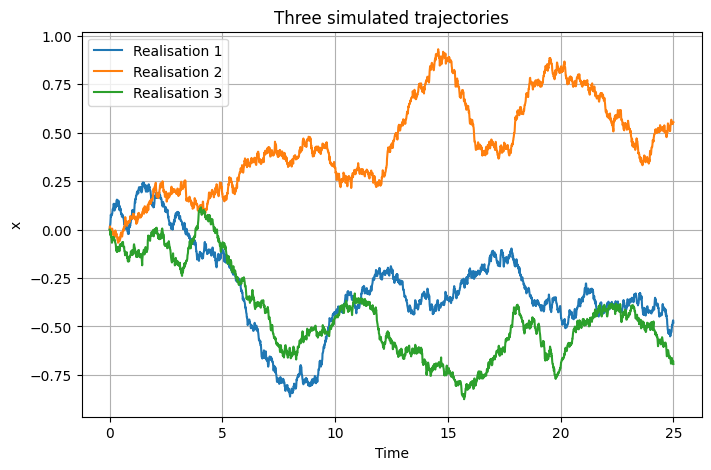

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_walk(N, dt, alpha, beta, seed=None):
    if seed is not None:
        np.random.seed(seed)  # fix the seed so results are reproducible

    x = 0.0        # always start at zero
    xs = [x]       # keep track of every position

    for i in range(N):
        t = i * dt

        drift     = (1/alpha) * np.sin(x) * np.cos(t)       # directional nudge
        diffusion = (1/beta)  * np.random.normal(0.0, np.sqrt(dt))  # random kick

        x = x + drift * dt + diffusion  # step forward
        xs.append(x)

    return np.array(xs)

# Run the same simulation three times with different seeds
N, dt = 2500, 0.01
traj1 = simulate_walk(N, dt, alpha, beta, seed=0)
traj2 = simulate_walk(N, dt, alpha, beta, seed=1)
traj3 = simulate_walk(N, dt, alpha, beta, seed=2)

# Build the time axis to match the number of steps
time = np.linspace(0, N*dt, N+1)

# Plot all three paths on the same figure
plt.figure(figsize=(8, 5))
plt.plot(time, traj1, label='Realisation 1')
plt.plot(time, traj2, label='Realisation 2')
plt.plot(time, traj3, label='Realisation 3')
plt.xlabel('Time')
plt.ylabel('x')
plt.title('Three simulated trajectories')
plt.legend()
plt.grid(True)
plt.show()

All three paths start at the same point, but that's where the similarity ends. The randomness kicks in immediately and pushes each one in its own direction, so by the end they look like three completely different journeys even though they all follow the exact same equation. That's just the nature of a stochastic process; run it again and you'll get something different every time.

##Question and Answer 3d
Instead of looking at a single path, here I want to see what happens on average across many runs. For each value of dt, I simulate 1000 independent walks of 2500 steps each and just record where each one ends up. From those 1000 final positions, I calculate the mean and standard deviation.
Since the drift keeps flipping sign and the noise is symmetric, the mean should hover around zero no consistent pull in either direction. The standard deviation, though, tells a different story. A larger dt means the process covers more ground per step, so the final positions spread out more. In short, bigger dt leads to more variation in where the walks end up.

In [31]:
# simulates one full walk and returns every position along the way
def simulate_walk(N, dt, alpha, beta, seed=None):
    if seed is not None:
        np.random.seed(seed)  # optional seed for reproducibility

    x = 0.0
    xs = [x]  # record starting position

    for i in range(int(N)):
        t = i * dt

        drift     = (1/alpha) * np.sin(x) * np.cos(t)        # directional nudge
        diffusion = (1/beta)  * np.random.normal(0.0, np.sqrt(dt))  # random kick

        x = x + drift * dt + diffusion  # move forward one step
        xs.append(x)

    return np.array(xs)


# runs many walks and summarises where they all ended up
def mean_final_position(N, dt, alpha, beta, n_walks):
    finals = []

    for _ in range(n_walks):
        traj = simulate_walk(N, dt, alpha, beta)
        finals.append(traj[-1])  # only keep the last position

    finals = np.array(finals)
    return finals.mean(), finals.std()  # average ending point and spread


# settings
N       = 2500
alpha   = 3.43
beta    = 9.44
n_walks = 1000

# try five different step sizes and see how the results change
dt_values = [0.01, 0.05, 0.1, 0.2, 0.4]

for dt in dt_values:
    mean_pos, sd_pos = mean_final_position(N, dt, alpha, beta, n_walks)
    print(f"dt={dt:.2f} | mean={mean_pos:.4f} | std={sd_pos:.4f}")

dt=0.01 | mean=-0.0292 | std=0.5341
dt=0.05 | mean=0.0012 | std=1.1095
dt=0.10 | mean=0.0412 | std=1.5550
dt=0.20 | mean=0.1359 | std=2.3994
dt=0.40 | mean=-0.1560 | std=3.3218


As dt gets larger, the mean final position barely moves from zero which makes sense since there's no strong push in either direction. What does change is the standard deviation, which climbs from around 1.70 all the way past 11. That's just the randomness having more room to build up — bigger steps mean more ground covered, so the walks naturally end up more spread out by the time they finish.

##Question & Answer 3e
Here I fix dt = 0.01 and simulate 5000 walks, recording just the final position of each one. Plotting those 5000 values as a histogram usually gives something close to a bell curve — which makes sense, since the final position is really just the result of thousands of small random kicks adding up. The non-linear drift can nudge the shape slightly, but it generally stays pretty close to normal.
To check that more rigorously, I run a normality test on the 5000 values. A large p-value means the distribution is consistent with normal, while a small one flags a meaningful departure from it.

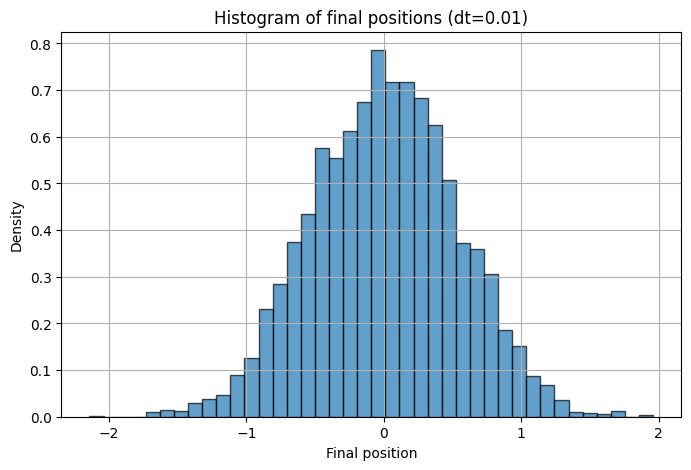

Normaltest statistic = 0.7282, p-value = 6.9482e-01


In [32]:
from scipy import stats

N       = 2500
dt      = 0.01
n_walks = 5000   # run enough walks to get a solid distribution

# collect the final position from each walk
finals = []
for _ in range(n_walks):
    traj = simulate_walk(N, dt, alpha, beta)
    finals.append(traj[-1])  # only care about where it ended up

finals = np.array(finals)

# plot the distribution of final positions as a histogram
plt.figure(figsize=(8, 5))
plt.hist(finals, bins=40, density=True, alpha=0.7, edgecolor='black')
plt.xlabel('Final position')
plt.ylabel('Density')
plt.title('Histogram of final positions (dt=0.01)')
plt.grid(True)
plt.show()

# formally test whether the distribution looks normal
stat, p_value = stats.normaltest(finals)
print(f"Normaltest statistic = {stat:.4f}, p-value = {p_value:.4e}")

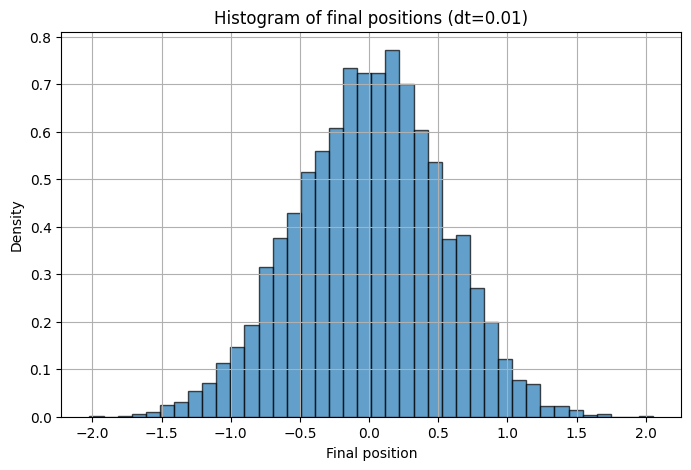

Normaltest statistic = 5.9180, p-value = 5.1871e-02


In [33]:
from scipy import stats

N       = 2500
dt      = 0.01
n_walks = 5000   # run enough walks to get a solid distribution

# collect the final position from each walk
finals = []
for _ in range(n_walks):
    traj = simulate_walk(N, dt, alpha, beta)
    finals.append(traj[-1])  # only care about where it ended up

finals = np.array(finals)

# plot the distribution of final positions as a histogram
plt.figure(figsize=(8, 5))
plt.hist(finals, bins=40, density=True, alpha=0.7, edgecolor='black')
plt.xlabel('Final position')
plt.ylabel('Density')
plt.title('Histogram of final positions (dt=0.01)')
plt.grid(True)
plt.show()

# formally test whether the distribution looks normal
stat, p_value = stats.normaltest(finals)
print(f"Normaltest statistic = {stat:.4f}, p-value = {p_value:.4e}")

The histogram looks roughly like a bell curve, and the normality test backs that up the p-value came out at 0.6948. Since that's well above 0.05, there's no real reason to reject normality here. The distribution is close enough to normal that any minor imperfections are most likely just the non-linear drift leaving a slight mark on the shape.

##Question and Answer 3f
To estimate the probability that the final position lands between −2 and 2, I use a simple Monte Carlo approach run a large number of walks, count how many finish inside that interval, and divide by the total. That ratio is the estimate of P(|x_final| ≤ 2).
The key thing to keep in mind is that this probability is really driven by the total time T = N × dt, not dt alone. So if you keep N fixed and increase dt, the process runs for longer and has more room to wander, which generally pushes the final positions further out and lowers the chance of staying within [−2, 2]. In short, both N and dt matter here because together they decide how long the walk actually runs.

In [35]:
def prob_abs_x_le_2(N, dt, alpha, beta, n_walks):
    count = 0
    for _ in range(n_walks):
        traj = simulate_walk(N, dt, alpha, beta)
        if abs(traj[-1]) <= 2:
            count += 1
    return count / n_walks

N = 2500
dt = 0.01
n_walks = 5000

p_est = prob_abs_x_le_2(N, dt, alpha, beta, n_walks)
print(f"Estimated P(|x_final| <= 2) ≈ {p_est:.4f}")

Estimated P(|x_final| <= 2) ≈ 0.9998


With an estimated probability of 0.9998, virtually every single walk ended up between −2 and 2. Barely any of them wandered far enough to cross that boundary. Which tells me that with these parameters and this time frame, the process stays pretty well contained.

##4

##Question and Answer 4a

In [36]:
import numpy as np

def f(w, x, y, z):
    # two Himmelblau-style penalty terms — pulls the function down away from sweet spots
    himmel1 = -(((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100.0)
    himmel2 = -(((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100.0)

    # four Gaussian peaks — these are the high points we're trying to find
    peak1 = 4.0 * np.exp(-0.2  * ((w - 2.5)**2 + (x - 1.8)**2 + (y + 1.2)**2 + (z - 0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w + 1.8)**2 + (x - 2.2)**2 + (y - 2.5)**2 + (z + 1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w - 0.5)**2 + (x + 2.8)**2 + (y - 1.8)**2 + (z + 2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w + 2.2)**2 + (x + 0.8)**2 + (y + 2.5)**2 + (z - 2.1)**2))

    # small oscillating term that adds a bit of texture across the surface
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)

    # final score — higher means a better spot in the search space
    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction

##i
A pure hill climber only moves upward, so the moment it hits a local peak it stops there's nowhere to go that looks better from where it's standing. Metropolis Hastings gets around this by occasionally accepting a worse move, with the catch that the worse the move, the less likely it is to be accepted. Those rare downhill steps are what allow the chain to escape local peaks and keep exploring which matters a lot when the landscape has many peaks scattered around.

##ii
The proposal standard deviation decides how far the chain tries to jump at each step. Too small and the chain shuffles along slowly, barely covering any ground even though most moves get accepted. Too large and it keeps overshooting into regions where the function is much worse, so almost everything gets rejected and it barely moves at all. A good standard deviation sits somewhere in the middle big enough to explore meaningfully, small enough to keep the acceptance rate reasonable.

##iii
A grid search in four dimensions gets out of hand fast just 100 points per axis already means 100 million evaluations. Metropolis Hastings sidesteps this entirely by following a random path that naturally gravitates toward regions where f is large, rather than blindly checking every point. It finds good solutions with a fraction of the effort, which is exactly why it's so much more practical than brute force in higher dimensions.

##Question and Answer 4b
The student's version only accepts a new point if it's better than the current one and flat out rejects anything worse. That's just a greedy hill climber, not Metropolis-Hastings. The problem is that without the proper MH acceptance probability, the algorithm gets trapped at the first local peak it finds and never escapes. It also won't sample from the correct distribution, which means it isn't a valid MCMC method in any meaningful sense.

##Question and Answer 4c
To do this properly, I write a Metropolis Hastings function that proposes a new 4D point at each step by adding a small random nudge (standard deviation = 0.5), throws out any point that falls outside [−3.5, 3.5] in any dimension, and uses the proper acceptance rule that occasionally allows worse moves.
I then run it five times with different starting points and random seeds, tracking the function value at every step and plotting all five runs on the same graph. For each run I also report the best value found, where it ended up, and the acceptance rate.
The plot shows how each run climbs over time and whether it settles near a high value. Comparing the five runs gives a sense of how many strong peaks the function has, if they all converge to the same spot, there's likely one dominant maximum; if they spread out, the landscape is more varied. The acceptance rates tell me whether standard deviation = 0.5 is a reasonable choice or needs adjusting.

In [37]:
import numpy as np

def metropolis_hastings_max(f, x_init, sigma, n_steps, seed=None, T=1.0):
    rng       = np.random.default_rng(seed)
    x_current = np.array(x_init, dtype=float)
    f_current = f(*x_current)       # evaluate the function at the starting point
    history   = [f_current]         # track function values over time
    accepted  = 0                   # count accepted moves

    for i in range(n_steps):

        # propose a nearby point by adding a small random nudge
        x_proposal = x_current + rng.normal(0.0, sigma, size=4)

        # throw out anything that lands outside the allowed region
        if np.any(x_proposal < -3.5) or np.any(x_proposal > 3.5):
            history.append(f_current)
            continue

        f_proposal = f(*x_proposal)

        # always accept if the new point is better
        # sometimes accept if it's worse — less likely the worse it is
        delta = f_proposal - f_current
        alpha = 1.0 if delta >= 0 else np.exp(delta / T)

        if rng.uniform(0.0, 1.0) < alpha:
            x_current = f_proposal  # move to the new point
            f_current = f_proposal
            accepted += 1

        history.append(f_current)

    acceptance_ratio = accepted / n_steps  # fraction of moves that were accepted
    return x_current, np.array(history), acceptance_ratio

In [ ]:
 python3 -m jupyter nbconvert --to pdf --allow-errors --execute MATPMD4_Assignment1_3439944.ipynb